## LASSO REGRESYONU

In [2]:
# Gerekli Kütüphanelerin indirilmesi
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as seabornInstance
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn import metrics
%matplotlib inline
import matplotlib
matplotlib.rcParams.update({"font.size":12})
from sklearn.linear_model import Lasso


In [3]:
# Veri setini indirelim.
veri= pd.read_excel("https://www.dropbox.com/s/luoopt5biecb04g/SATILK_EV1.xlsx?dl=1",index_col=0)
veri.head()

,Fiyat,Oda_Sayısı,Net_m2,Katı,Yaşı
0,475,1,40,0,6
1,475,1,55,0,5
2,450,1,50,0,7
3,450,1,55,1,6
4,475,1,45,2,7


In [4]:
# Hedef ve öznitelik değişkenlerini (x) tanımlayalım:
x=veri [["Oda_Sayısı","Net_m2","Katı","Yaşı"]]
y=veri["Fiyat"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [5]:
# Lasso algoritmasını eğitiyoruz.
lasso =Lasso()
lasso.fit(x_train,y_train)
train_score=lasso.score(x_train,y_train)
test_score=lasso.score(x_test,y_test)
coeff_used=np.sum(lasso.coef_!=0)

#alpha L1 in parametresiidr katsasıyısıdr.sen girmezsen deger default 1 olur. ceza katsayısııdr.
print("Eğitim Verisi için R2: ",train_score)
print("Test verisi için R2: ",test_score)
print("Kullanılan Önitelik Sayısı (Ağırlığı sıfırdan büyük): ",coeff_used)#demek ki hiç kaldırılan öznitelik olmadı.



Eğitim Verisi için R2:  0.7324650909211012
Test verisi için R2:  0.6862906745619393
Kullanılan Önitelik Sayısı (Ağırlığı sıfırdan büyük):  4


In [6]:
# Lasso (alpha=0.01):
lasso001=Lasso(alpha=0.01,max_iter=100000)
lasso001.fit(x_train,y_train)


train_score001=lasso001.score(x_train,y_train)
test_score001=lasso001.score(x_test,y_test)
coeff_used001=np.sum(lasso001.coef_!=0)

print("Eğitim Verisi için R2(alpha=0.01): ",train_score001)
print("Test verisi için R2:(alpha=0.01) ",test_score001)
print("Kullanılan Önitelik Sayısı (alpha=0.01): ",coeff_used001)

Eğitim Verisi için R2(alpha=0.01):  0.7337398316689662
Test verisi için R2:(alpha=0.01)  0.6986142688656936
Kullanılan Önitelik Sayısı (alpha=0.01):  4


In [7]:
# Lasso (alpha=0.001):
lasso0001=Lasso(alpha=0.001,max_iter=100000)
lasso0001.fit(x_train,y_train)

train_score0001=lasso0001.score(x_train,y_train)
test_score0001=lasso0001.score(x_test,y_test)
coeff_used0001=np.sum(lasso0001.coef_!=0)

print("Eğitim Verisi için R2(alpha=0.001): ",train_score0001)
print("Test verisi için R2:(alpha=0.001) ",test_score0001)
print("Kullanılan Önitelik Sayısı (alpha=0.001): ",coeff_used0001)

Eğitim Verisi için R2(alpha=0.001):  0.7337399603541521
Test verisi için R2:(alpha=0.001)  0.6987168382749434
Kullanılan Önitelik Sayısı (alpha=0.001):  4


In [8]:
#Doğrusal regresyon tahmini
lr=LinearRegression()
lr.fit(x_train,y_train)
lr_train_score=lr.score(x_train,y_train)
lr_test_score=lr.score(x_test,y_test)

print("Eğitim setinin R2 si",lr_train_score)
print("Test setinin R2 si: ",lr_test_score)


Eğitim setinin R2 si 0.733739961656849
Test setinin R2 si:  0.6987282352837989


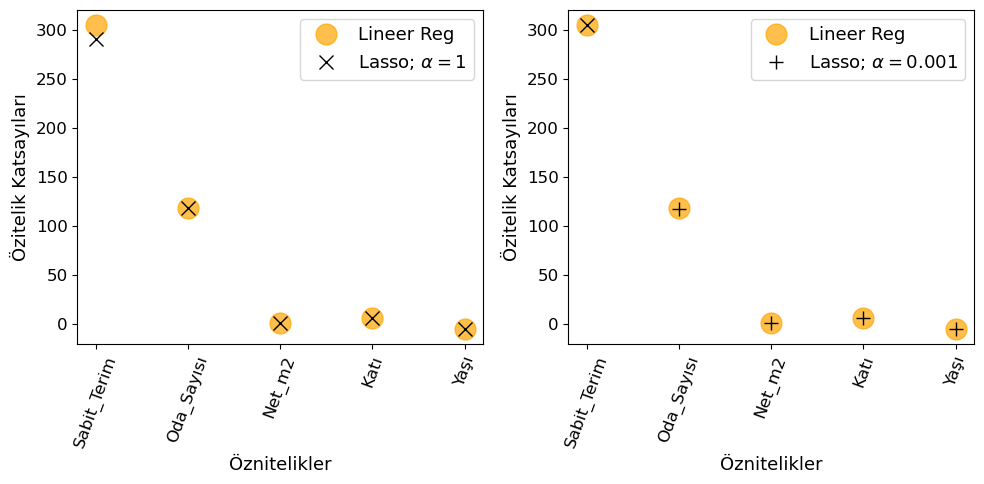

In [9]:
#Grafik :Lasso (alpha 1 ve 0.001) ile Linear Regresyon karşılaştırması
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot((1,2,3,4),lr.coef_,alpha=0.7,linestyle="none",marker="o",markersize=15,color="orange",label="Lineer Reg",zorder=2)
plt.plot((1,2,3,4),lr.coef_,alpha=1,linestyle="none",marker="x",markersize=10,color="black",label=r"Lasso; $\alpha =1$",zorder=7)
plt.plot(0,lr.intercept_,alpha=0.7,linestyle="none",marker="o",markersize=15,color="orange")
plt.plot(0,lasso.intercept_,alpha=1,linestyle="none",marker="x",markersize=10,color="black")

plt.xticks([0,1,2,3,4],("Sabit_Terim","Oda_Sayısı","Net_m2","Katı","Yaşı"),rotation=70)
plt.xlabel("Öznitelikler",fontsize=13)
plt.ylabel("Özitelik Katsayıları",fontsize=13)
plt.legend(fontsize=13,loc="upper right")
plt.subplot(1,2,2)

plt.plot((1,2,3,4),lr.coef_,alpha=0.7,linestyle="none",marker="o",markersize=15,color="orange",label="Lineer Reg",zorder=2)
plt.plot((1,2,3,4),lasso001.coef_,alpha=1,linestyle="none",marker="+",markersize=10,color="black",label=r"Lasso; $\alpha =0.001$")
plt.plot(0,lr.intercept_,alpha=0.7,linestyle="none",marker="o",markersize=15,color="orange")
plt.plot(0,lasso001.intercept_,alpha=1,linestyle="none",marker="x",markersize=10,color="black")

plt.xticks([0,1,2,3,4],("Sabit_Terim","Oda_Sayısı","Net_m2","Katı","Yaşı"),rotation=70)
plt.xlabel("Öznitelikler",fontsize=13)
plt.ylabel("Özitelik Katsayıları",fontsize=13)
plt.legend(fontsize=13,loc="upper right")
plt.tight_layout()
plt.show()
